# Logistic Regression on Diabetes Dataset


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 1. Data Exploration

a.Load the dataset and perform exploratory data analysis (EDA).

In [ ]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


b.Examine the features, their types, and summary statistics.

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


C.Create visualizations such as histograms, box plots, or pair plots to visualize the distributions and relationships between features.
Analyze any patterns or correlations observed in the data.


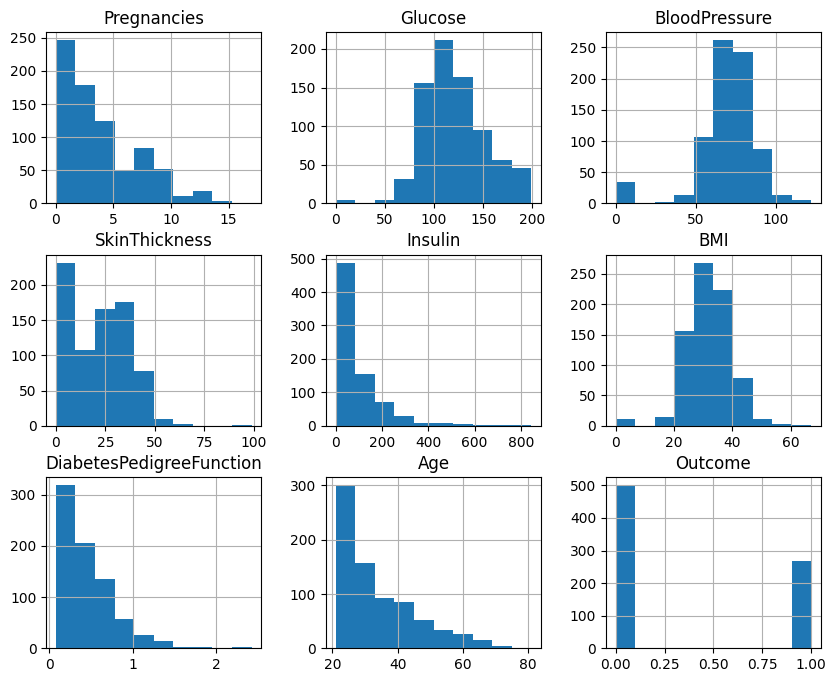

In [ ]:
df.hist(figsize=(10,8))
plt.show()

## 2. Data Preprocessing

In [ ]:
import numpy as np

cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df[cols_with_zero] = df[cols_with_zero].replace(0, np.nan)

In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
df.fillna(df.median(), inplace=True)

## 3. Model Building

In [ ]:
# 3. Model Building



from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Features and target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling (important for Logistic Regression)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build model
model = LogisticRegression(max_iter=1000)

# Train model
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## 4. Model Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

y_pred = model.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred))
print('F1 Score:', f1_score(y_test, y_pred))
print('ROC AUC:', roc_auc_score(y_test, y_pred))

Accuracy: 0.7467532467532467
Precision: 0.6379310344827587
Recall: 0.6727272727272727
F1 Score: 0.6548672566371682
ROC AUC: 0.7303030303030302


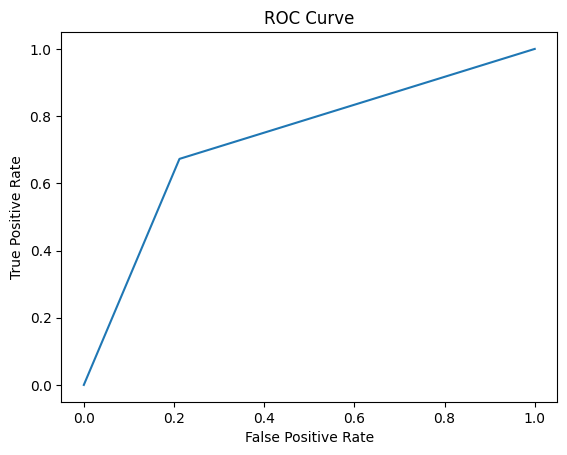

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_pred)
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

## 5. Interpretation



#### **a. Interpretation of Coefficients**

* **Positive coefficient** → increases survival probability
* **Negative coefficient** → decreases survival probability

**Based on your data:**

* **Sex (male)** → negative → males less likely to survive
* **Pclass** → negative → lower class (3rd) → lower survival
* **Age** → slightly negative → older passengers less likely to survive
* **Fare** → positive → higher fare → higher survival




#### **b. Significance of Features**

* **Most significant:** Sex, Pclass
* **Moderate:** Fare, Age
* **Least significant:** Embarked




6. Deployment with Streamlit:

In [1]:
Local URL: http://localhost:8501






import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

# Sidebar title
st.sidebar.title("Diabetes Data App")

# Load dataset
df = pd.read_csv("diabetes.csv")

# Sidebar options
option = st.sidebar.selectbox(
    "Choose an option:",
    ("Display Data", "Top 5 Glucose Values", "Plot Outcome Count")
)

# Button
if st.sidebar.button("Submit"):
    st.write(f"You selected: {option}")

    # 1. Display full dataset
    if option == "Display Data":
        st.write(df)

    # 2. Top 5 highest glucose values
    if option == "Top 5 Glucose Values":
        top_glucose = df.nlargest(5, 'Glucose')
        st.write(top_glucose)

    # 3. Plot Outcome distribution
    if option == "Plot Outcome Count":
        outcome_counts = df['Outcome'].value_counts()

        fig, ax = plt.subplots()
        outcome_counts.plot(kind='bar', ax=ax)

        ax.set_title("Diabetes Outcome Count")
        ax.set_xlabel("Outcome (0 = No, 1 = Yes)")
        ax.set_ylabel("Count")

        st.pyplot(fig)

Interview Questions

1.Difference between Precision and Recall:

Precision:
Out of all predicted positives, how many are actually positive
Precision = focus on correctness of positive predictions

Recall (Sensitivity):
Out of all actual positives, how many are correctly predicted
Recall = focus on capturing all actual positives



2.What is Cross-Validation and why it’s important?

Cross-validation splits data into multiple folds to train and test the model multiple times.

Purpose:
Prevent overfitting
Ensure model performance is generalizable
Gives a better estimate of accuracy on unseen data
